In [2]:
import os
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 경로 설정
DATA_ROOT = "../dataset/flickr8k"
CAPTIONS_PATH = os.path.join(DATA_ROOT, "captions.txt")
IMAGES_PATH = os.path.join(DATA_ROOT, "Images")

## 1. 기본 데이터 정보

- **캡션 파일 형식**: `captions.txt` - `이미지이름,caption` (CSV 형식)

In [3]:
# captions.txt 로드 (이미지이름 - 캡션 형식)
df = pd.read_csv(CAPTIONS_PATH)
df.columns = ['image', 'caption']

# 기본 통계
total_images = df['image'].nunique()
total_captions = len(df)
captions_per_image = df.groupby('image').size()

print("=" * 50)
print("📊 기본 데이터 통계")
print("=" * 50)
print(f"전체 이미지 수: {total_images:,}개")
print(f"전체 캡션 수: {total_captions:,}개")
cpi_min, cpi_max = captions_per_image.min(), captions_per_image.max()
cpi_str = f"{cpi_min}개" if cpi_min == cpi_max else f"{cpi_min}~{cpi_max}개"
print(f"이미지 1개당 캡션 수: {cpi_str}")
print(f"캡션/이미지 비율: {total_captions/total_images:.1f}")

📊 기본 데이터 통계
전체 이미지 수: 8,091개
전체 캡션 수: 40,455개
이미지 1개당 캡션 수: 5개
캡션/이미지 비율: 5.0


In [4]:
# 이미지별 캡션 수 분포 확인
caption_counts = captions_per_image.value_counts().sort_index()
print("이미지별 캡션 개수 분포:")
print(caption_counts)
print(f"\n캡션 수 통계: min={captions_per_image.min()}, max={captions_per_image.max()}, mean={captions_per_image.mean():.2f}")

이미지별 캡션 개수 분포:
5    8091
Name: count, dtype: int64

캡션 수 통계: min=5, max=5, mean=5.00


## 2. 캡션 텍스트 분석

In [5]:
# 캡션 길이 분석 (단어 수, 문자 수)
df['word_count'] = df['caption'].str.split().str.len()
df['char_count'] = df['caption'].str.len()

print("📝 캡션 길이 통계 (단어 기준)")
print("-" * 40)
print(f"최소 단어 수: {df['word_count'].min()}")
print(f"최대 단어 수: {df['word_count'].max()}")
print(f"평균 단어 수: {df['word_count'].mean():.2f}")
print(f"중앙값: {df['word_count'].median():.0f}")
print(f"표준편차: {df['word_count'].std():.2f}")

print("\n📝 캡션 길이 통계 (문자 기준)")
print("-" * 40)
print(f"최소 문자 수: {df['char_count'].min()}")
print(f"최대 문자 수: {df['char_count'].max()}")
print(f"평균 문자 수: {df['char_count'].mean():.2f}")

📝 캡션 길이 통계 (단어 기준)
----------------------------------------
최소 단어 수: 1
최대 단어 수: 38
평균 단어 수: 11.78
중앙값: 11
표준편차: 3.89

📝 캡션 길이 통계 (문자 기준)
----------------------------------------
최소 문자 수: 1
최대 문자 수: 199
평균 문자 수: 55.13


In [7]:
# 최소 길이(단어 수 1 또는 문자 수 1) 캡션 확인
min_word = df[df['word_count'] == 1]
min_char = df[df['char_count'] == 1]

print("🔍 단어 수가 1인 캡션:")
print("-" * 40)
if len(min_word) > 0:
    for _, row in min_word.iterrows():
        print(f"  이미지: {row['image']}")
        print(f"  캡션: '{row['caption']}' (repr: {repr(row['caption'])})")
    print(f"\n총 {len(min_word)}개")
else:
    print("  없음")

print("\n🔍 문자 수가 1인 캡션:")
print("-" * 40)
if len(min_char) > 0:
    for _, row in min_char.iterrows():
        print(f"  이미지: {row['image']}")
        print(f"  캡션: '{row['caption']}' (repr: {repr(row['caption'])})")
    print(f"\n총 {len(min_char)}개")
else:
    print("  없음")

🔍 단어 수가 1인 캡션:
----------------------------------------
  이미지: 2428275562_4bde2bc5ea.jpg
  캡션: 'A' (repr: 'A')
  이미지: 3640443200_b8066f37f6.jpg
  캡션: 'a' (repr: 'a')

총 2개

🔍 문자 수가 1인 캡션:
----------------------------------------
  이미지: 2428275562_4bde2bc5ea.jpg
  캡션: 'A' (repr: 'A')
  이미지: 3640443200_b8066f37f6.jpg
  캡션: 'a' (repr: 'a')

총 2개


In [13]:
# 2단어 이하 캡션 통계 (학습 시 배제 대상)
short_captions = df[df['word_count'] <= 2]
images_with_short = short_captions['image'].nunique()

print("📊 2단어 이하 캡션 통계")
print("-" * 40)
print(f"2단어 이하 캡션 수: {len(short_captions):,}개 (전체의 {len(short_captions)/len(df)*100:.2f}%)")
print(f"해당 이미지 수: {images_with_short:,}개 (전체의 {images_with_short/total_images*100:.2f}%)")
print(f"\n단어 수별 분포:")
print(short_captions['word_count'].value_counts().sort_index().to_string())

📊 2단어 이하 캡션 통계
----------------------------------------
2단어 이하 캡션 수: 17개 (전체의 0.04%)
해당 이미지 수: 17개 (전체의 0.21%)

단어 수별 분포:
word_count
1     2
2    15


In [6]:
# 어휘(Vocabulary) 분석
all_words = []
for caption in df['caption']:
    words = str(caption).lower().replace('.', '').replace(',', '').split()
    all_words.extend(words)

word_freq = Counter(all_words)
vocab_size = len(word_freq)
total_tokens = len(all_words)

print("📚 어휘(Vocabulary) 통계")
print("-" * 40)
print(f"전체 토큰(단어) 수: {total_tokens:,}")
print(f"고유 단어 수 (Vocabulary Size): {vocab_size:,}")
print(f"평균 문서당 고유단어 비율: {vocab_size/total_captions*100:.2f}%")

print("\n🔤 가장 많이 등장하는 단어 Top 20:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count:,}회")

📚 어휘(Vocabulary) 통계
----------------------------------------
전체 토큰(단어) 수: 436,856
고유 단어 수 (Vocabulary Size): 8,911
평균 문서당 고유단어 비율: 22.03%

🔤 가장 많이 등장하는 단어 Top 20:
  a: 62,986회
  in: 18,974회
  the: 18,418회
  on: 10,743회
  is: 9,345회
  and: 8,851회
  dog: 8,136회
  with: 7,765회
  man: 7,265회
  of: 6,713회
  two: 5,638회
  white: 3,940회
  black: 3,832회
  boy: 3,581회
  are: 3,504회
  woman: 3,402회
  girl: 3,328회
  to: 3,173회
  wearing: 3,062회
  at: 2,914회


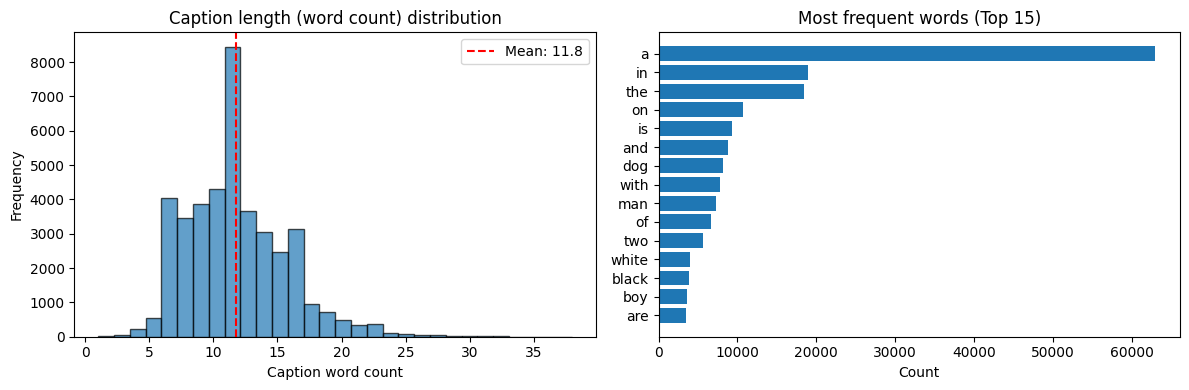

In [14]:
# 시각화: 캡션 길이 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['word_count'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Caption word count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Caption length (word count) distribution')
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.1f}')
axes[0].legend()

# 상위 20 단어 막대그래프
top_words = word_freq.most_common(15)
axes[1].barh([w[0] for w in reversed(top_words)], [w[1] for w in reversed(top_words)])
axes[1].set_xlabel('Count')
axes[1].set_title('Most frequent words (Top 15)')
plt.tight_layout()
plt.show()

## 3. 이미지 메타데이터 분석

In [9]:
# 이미지 파일 존재 여부 및 해상도 샘플링
image_files = set(os.listdir(IMAGES_PATH))
caption_images = set(df['image'].unique())

# 캡션에 있지만 이미지 폴더에 없는 파일 (또는 그 반대)
missing_images = caption_images - image_files
extra_images = image_files - caption_images

print("🖼️ 이미지-캡션 매칭 확인")
print("-" * 40)
print(f"Images 폴더 내 파일 수: {len(image_files):,}")
print(f"캡션에 등장하는 고유 이미지 수: {len(caption_images):,}")
print(f"캡션에 있으나 이미지 없는 파일: {len(missing_images)}개")
print(f"이미지는 있으나 캡션 없는 파일: {len(extra_images)}개")

# 샘플 이미지 해상도 분석 (전체 로드 시 시간 소요되므로 샘플링)
sample_size = min(500, len(image_files))
sample_images = list(image_files)[:sample_size]
resolutions = []
for img_name in sample_images:
    try:
        img_path = os.path.join(IMAGES_PATH, img_name)
        with Image.open(img_path) as img:
            resolutions.append(img.size)
    except Exception as e:
        pass

if resolutions:
    widths, heights = zip(*resolutions)
    print(f"\n📐 이미지 해상도 (샘플 {len(resolutions)}장)")
    print("-" * 40)
    print(f"가로: min={min(widths)}, max={max(widths)}, 평균={np.mean(widths):.0f}")
    print(f"세로: min={min(heights)}, max={max(heights)}, 평균={np.mean(heights):.0f}")

🖼️ 이미지-캡션 매칭 확인
----------------------------------------
Images 폴더 내 파일 수: 8,091
캡션에 등장하는 고유 이미지 수: 8,091
캡션에 있으나 이미지 없는 파일: 0개
이미지는 있으나 캡션 없는 파일: 0개

📐 이미지 해상도 (샘플 500장)
----------------------------------------
가로: min=289, max=500, 평균=458
세로: min=202, max=500, 평균=401


## 4. 캡션 패턴 분석

In [10]:
# 캡션 시작 패턴 (예: "A dog", "Two people" 등)
start_words = df['caption'].str.split().str[0].value_counts()
print("📌 캡션 첫 단어 분포 (Top 15)")
print("-" * 40)
print(start_words.head(15).to_string())

# 대소문자 통일 후 "a"로 시작하는 비율 (영어 관사/수량 표현)
a_start = df['caption'].str.strip().str.lower().str.startswith('a ')
the_start = df['caption'].str.strip().str.lower().str.startswith('the ')
print(f"\n'A '로 시작하는 캡션: {a_start.sum():,}개 ({a_start.mean()*100:.1f}%)")
print(f"'The '로 시작하는 캡션: {the_start.sum():,}개 ({the_start.mean()*100:.1f}%)")

📌 캡션 첫 단어 분포 (Top 15)
----------------------------------------
caption
A          22665
Two         4365
The         3085
a           2039
Three       1079
An           487
People       435
Man          434
two          362
Four         360
There        269
One          209
Several      201
Young        198
Woman        171

'A '로 시작하는 캡션: 24,702개 (61.1%)
'The '로 시작하는 캡션: 3,121개 (7.7%)


In [11]:
# 캡션에 등장하는 주요 객체/동물 키워드
keywords = ['dog', 'dogs', 'person', 'people', 'man', 'woman', 'child', 'children', 'boy', 'girl', 
            'cat', 'bird', 'horse', 'car', 'bike', 'ball', 'water', 'grass', 'beach', 'street']
keyword_counts = {}
for kw in keywords:
    count = df['caption'].str.lower().str.contains(rf'\b{kw}\b', regex=True).sum()
    keyword_counts[kw] = count

print("🏷️ 주요 키워드 등장 빈도 (캡션 내)")
print("-" * 40)
for kw, cnt in sorted(keyword_counts.items(), key=lambda x: -x[1]):
    pct = cnt / total_captions * 100
    print(f"  {kw}: {cnt:,}회 ({pct:.1f}%)")

🏷️ 주요 키워드 등장 빈도 (캡션 내)
----------------------------------------
  dog: 7,440회 (18.4%)
  man: 7,015회 (17.3%)
  boy: 3,477회 (8.6%)
  woman: 3,331회 (8.2%)
  girl: 3,222회 (8.0%)
  people: 2,862회 (7.1%)
  water: 2,741회 (6.8%)
  dogs: 2,113회 (5.2%)
  ball: 1,777회 (4.4%)
  grass: 1,620회 (4.0%)
  person: 1,521회 (3.8%)
  child: 1,510회 (3.7%)
  children: 1,154회 (2.9%)
  beach: 1,041회 (2.6%)
  street: 940회 (2.3%)
  bike: 847회 (2.1%)
  car: 419회 (1.0%)
  horse: 230회 (0.6%)
  bird: 193회 (0.5%)
  cat: 65회 (0.2%)


In [12]:
# 같은 이미지에 대한 캡션 다양성 (예시)
sample_img = df['image'].iloc[0]
sample_captions = df[df['image'] == sample_img]['caption'].tolist()
print(f"📷 샘플 이미지: {sample_img}")
print("-" * 40)
for i, cap in enumerate(sample_captions, 1):
    print(f"  {i}. {cap}")

📷 샘플 이미지: 1000268201_693b08cb0e.jpg
----------------------------------------
  1. A child in a pink dress is climbing up a set of stairs in an entry way .
  2. A girl going into a wooden building .
  3. A little girl climbing into a wooden playhouse .
  4. A little girl climbing the stairs to her playhouse .
  5. A little girl in a pink dress going into a wooden cabin .


## 5. 코드로 확인할 수 없는 정보 (수동 관찰용)

아래 항목들은 코드로 자동 분석하기 어려우며, **직접 이미지와 캡션을 살펴보며 기록**해 주세요.

| 항목 | 관찰 내용 |
|------|----------|
| **이미지 내 사람 수** | 대략 몇 명 정도가 나오는가? (0명, 1명, 2~5명, 6명 이상 등) |
| **캡션 표현 스타일** | 어떤 표현이 많은가? (예: "A ~ is ~ing", "~ in/on the ~", 행동 위주 vs 상태 위주) |
| **캡션의 구체성** | 추상적 vs 구체적 (색상, 옷, 배경 등 세부 묘사 수준) |
| **캡션 간 일관성** | 같은 이미지의 5개 캡션이 서로 얼마나 유사/다양한가? |
| **이미지 장면 유형** | 실내/실외, 인물/동물/풍경 비율, 시간대(낮/밤) 등 |
| **캡션 오류** | 이미지와 맞지 않는 캡션, 오타, 문법 오류 등 |
| **다양성** | 장면/객체/활동의 다양성 수준 |